In [ ]:

!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 55.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 107.2 MB/s eta 0:00:0000:0100:01


In [ ]:
import torch
import torchvision
from torchvision import transforms, datasets
from torchvision.transforms import ToTensor
import torch.optim as optim
import torch.nn as nn
import pennylane as qml
from pennylane import numpy as np

use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

In [ ]:
transform = transforms.Compose([
    #transforms.Grayscale(num_output_channels=1),
    #transforms.Resize((28, 28)),
    transforms.ToTensor()
])
train_data = datasets.CIFAR10(root='data', train=True, download=True, transform=transform)
test_data = datasets.CIFAR10(root='data', train=False, transform=transform)


100%|██████████| 170M/170M [00:05<00:00, 29.8MB/s] 


Extracting data/cifar-10-python.tar.gz to data


In [ ]:
from torch.utils.data import Subset

subset_train_size = 30000  #
train_indices = torch.randperm(len(train_data))[:subset_train_size]
train_data = Subset(train_data, train_indices)

subset_test_size = 7000  #
test_indices = torch.randperm(len(test_data))[:subset_test_size]
test_data = Subset(test_data, test_indices)


In [ ]:
class ClassicalCNN(nn.Module):
    def __init__(self):
        super(ClassicalCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.5)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.dropout2 = nn.Dropout(0.25)
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # [batch, 64, 16, 16]
        x = self.dropout1(x)
        x = self.pool(F.relu(self.conv2(x)))  # [batch, 64, 8, 8]
        x = self.dropout2(x)
        x = x.view(-1, 64 * 8 * 8)  # [batch, 4096]
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score,classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import tqdm
import torch.nn.functional as F

def train_classical_cnn(model, train_loader, val_loader, num_epochs=50, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_acc = 0.0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Validation
        val_loss, val_acc = evaluate_model1(model, val_loader, criterion)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_classical_cnn.pth')

        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% - "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    # Plot training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.legend()
    plt.show()

    return model

def evaluate_model(model, loader, criterion=None):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            if criterion:
                loss = criterion(outputs, labels)
                total_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    avg_loss = total_loss / len(loader) if criterion else None

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    print(f"Accuracy: {accuracy:.2f}%")
    print(f"Classification Report:\n{classification_report(all_labels, all_preds)}")

    return avg_loss, accuracy

def evaluate_model1(model, loader, criterion=None):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            if criterion:
                loss = criterion(outputs, labels)
                total_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    avg_loss = total_loss / len(loader) if criterion else None

    return avg_loss, accuracy


## Quantum Hidden Layers added

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import pennylane as qml

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    qml.templates.IQPEmbedding(inputs, wires=range(n_qubits))
    #qml.ZZFeatureMap(inputs,n_qubits, repetitions=1,wires=range(n_qubits))
    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

weight_shapes = {"weights": (2, n_qubits, 3)}  # 2 quantum circuit layers

class HybridQuantumCNN(nn.Module):
    def __init__(self):
        super(HybridQuantumCNN, self).__init__()
        # Classical CNN part (same as original)
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        # Quantum preparation (2 parallel quantum circuits)
        self.fc1 = nn.Linear(32 * 8 * 8, 64)
        self.q_prep1 = nn.Linear(32, n_qubits)  # First branch
        self.q_prep2 = nn.Linear(32, n_qubits)  # Second branch
        self.qlayer1 = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)
        self.qlayer2 = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)

        self.res_proj = nn.Linear(64, n_qubits * 2)

        # Output layer
        self.fc_out = nn.Linear(n_qubits * 2*2, 10)  # 2 quantum layers × n qubits

    def forward(self, x):
        # Classical processing
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = x.view(-1, 32 * 8 * 8)
        x_classical = F.relu(self.fc1(x))

        # Split for 2 quantum circuits
        x1, x2 = torch.split(x_classical, 32, dim=1)
        x1_quantum = self.qlayer1(self.q_prep1(x1))
        x2_quantum = self.qlayer2(self.q_prep2(x2))
        x_quantum = torch.cat([x1_quantum, x2_quantum], dim=1)


        x_residual = self.res_proj(x_classical)

        # Combine quantum + residual
        x_combined = torch.cat([x_quantum, x_residual], dim=1)
        x_out = self.fc_out(x_combined)

        return x_out

In [ ]:
import torch
import datetime

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def train_quantum_cnn(model, train_loader, val_loader, num_epochs=10, lr=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam([
        {'params': [p for n, p in model.named_parameters() if 'qlayer' not in n], 'lr': lr},
        {'params': [p for n, p in model.named_parameters() if 'qlayer' in n], 'lr': lr*3}
    ])

    best_val_acc = 0.0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in (train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Validation
        val_loss, val_acc = evaluate_model1(model, val_loader, criterion)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_quantum_cnn.pth')

        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% - "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    # Plot training history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Acc')
    plt.plot(val_accs, label='Val Acc')
    plt.legend()
    plt.show()

    return model



Using device: cuda


In [ ]:
# Initialize and train Quantum CNN
quantum_cnn = HybridQuantumCNN()
quantum_cnn = train_quantum_cnn(quantum_cnn, train_loader, val_loader, num_epochs=20)



Epoch 1/20 - Train Loss: 1.6592, Train Acc: 38.84% - Val Loss: 1.4514, Val Acc: 46.44%
Epoch 2/20 - Train Loss: 1.2817, Train Acc: 53.82% - Val Loss: 1.1613, Val Acc: 58.68%
Epoch 3/20 - Train Loss: 1.1238, Train Acc: 59.94% - Val Loss: 1.1101, Val Acc: 61.55%
Epoch 4/20 - Train Loss: 1.1395, Train Acc: 59.70% - Val Loss: 1.2569, Val Acc: 55.49%
Epoch 5/20 - Train Loss: 1.0846, Train Acc: 62.00% - Val Loss: 1.0978, Val Acc: 61.91%
Epoch 6/20 - Train Loss: 0.9686, Train Acc: 65.88% - Val Loss: 1.0775, Val Acc: 61.84%
Epoch 7/20 - Train Loss: 0.9384, Train Acc: 66.82% - Val Loss: 1.0747, Val Acc: 63.33%
Epoch 8/20 - Train Loss: 0.8773, Train Acc: 69.02% - Val Loss: 1.0699, Val Acc: 63.24%
Epoch 9/20 - Train Loss: 0.8356, Train Acc: 70.45% - Val Loss: 1.0255, Val Acc: 64.65%
Epoch 10/20 - Train Loss: 0.7873, Train Acc: 72.33% - Val Loss: 1.0367, Val Acc: 64.92%
Epoch 11/20 - Train Loss: 0.7600, Train Acc: 73.00% - Val Loss: 1.0268, Val Acc: 65.69%
Epoch 12/20 - Train Loss: 0.7241, Train A

KeyboardInterrupt: 


Quantum-enhanced CNN Test Results:


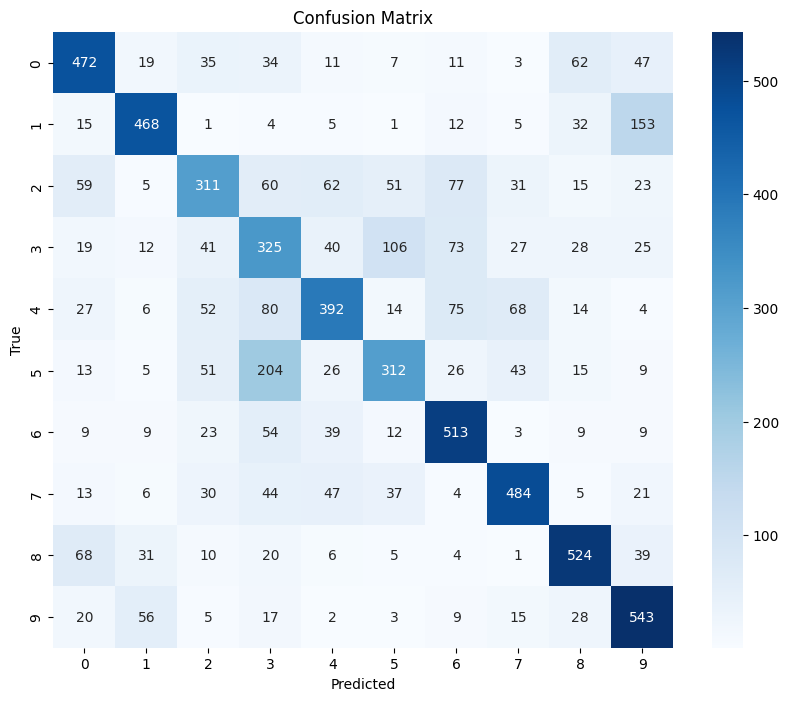

Accuracy: 62.06%
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.67      0.67       701
           1       0.76      0.67      0.71       696
           2       0.56      0.45      0.50       694
           3       0.39      0.47      0.42       696
           4       0.62      0.54      0.58       732
           5       0.57      0.44      0.50       704
           6       0.64      0.75      0.69       680
           7       0.71      0.70      0.71       691
           8       0.72      0.74      0.73       708
           9       0.62      0.78      0.69       698

    accuracy                           0.62      7000
   macro avg       0.62      0.62      0.62      7000
weighted avg       0.62      0.62      0.62      7000



(None, 62.05714285714286)

In [ ]:
# Evaluate on test set
print("\nQuantum-enhanced CNN Test Results:")
evaluate_model(quantum_cnn, test_loader)

In [ ]:
torch.save(quantum_cnn.state_dict(),'hiddenquanvmodeldictfinal.pth')